# Aula 7: X do SARIMAX, Auto ARIMA

- Revisão
    - AR, MA
    - I
    - S
    
- ARIMAX:
    - Como decidir se uma variável é útil
    - CCF
    


In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes, correlacao_cruzada
plt.rcParams["figure.figsize"] = [12, 5]
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [6]:
df = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/clicks_original.csv')
df.index = pd.to_datetime(df['date'])
df = df.drop(['date'], axis=1)
df.index.freq = 'D'
df = df[:-1] # Tirando o último ponto por ser um outlier, vou discutir isso depois
df

/var/folders/f1/tdh3lyp114g78tg5wv2t7g3m0000gn/T/ipykernel_16810/1031137758.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df['date'])


,price,location,clicks
date,,,
2008-04-01,43.155647,2,18784
2008-04-02,43.079056,1,24738
2008-04-03,43.842609,2,15209
2008-04-04,43.312376,1,14018
2008-04-05,43.941176,1,11974
...,...,...,...
2008-08-08,43.730836,1,13744
2008-08-09,44.182033,1,6716
2008-08-10,43.608260,1,9523


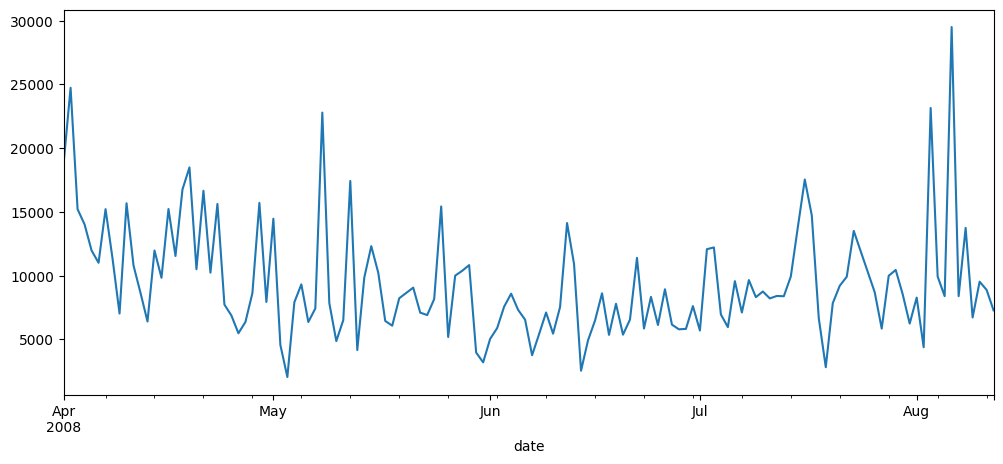

('Não Estacionário', 'Estacionário')

In [9]:
y = df['clicks']
y.plot()
plt.show()
teste_estacionariedade(y)

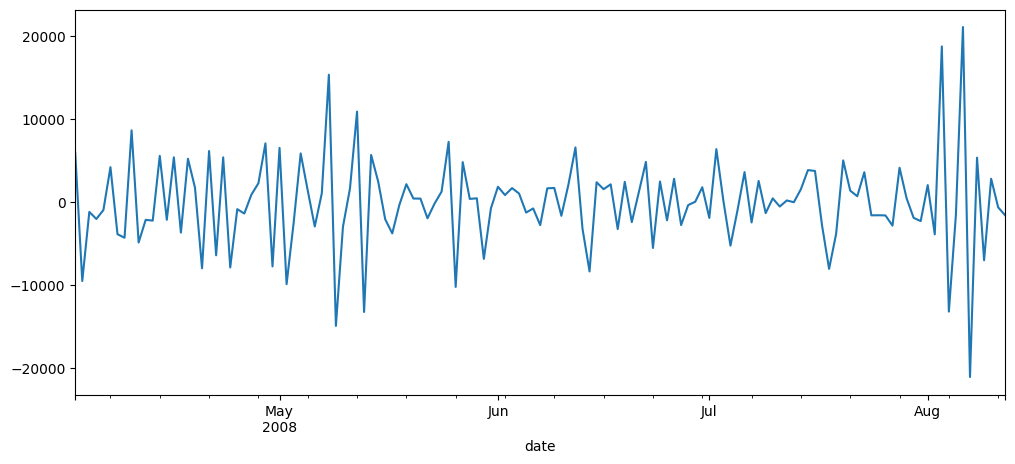

('Estacionário', 'Estacionário')

In [10]:
primeira_ordem = y.diff().dropna()
primeira_ordem.plot()
plt.show()
teste_estacionariedade(primeira_ordem)

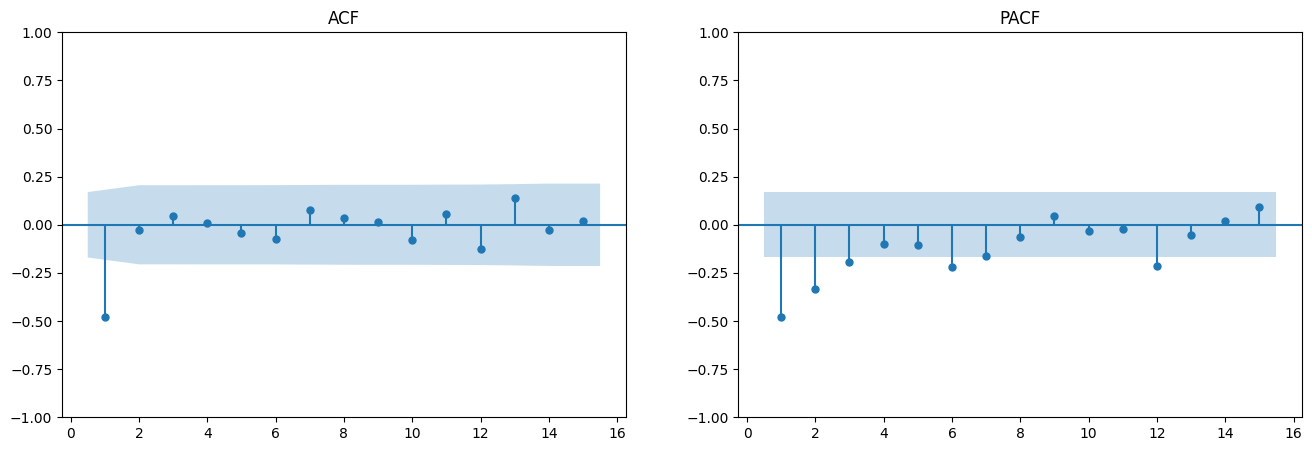

In [11]:
all_ac(primeira_ordem)

                               SARIMAX Results                                
Dep. Variable:                 clicks   No. Observations:                  134
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1301.175
Date:                Sun, 16 Mar 2025   AIC                           2606.350
Time:                        21:04:46   BIC                           2612.131
Sample:                    04-01-2008   HQIC                          2608.699
                         - 08-12-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9070      0.041    -22.370      0.000      -0.986      -0.828
sigma2      2.017e+07   9.42e-11   2.14e+17      0.000    2.02e+07    2.02e+07
Ljung-Box (L1) (Q):                   0.07   Jarque-

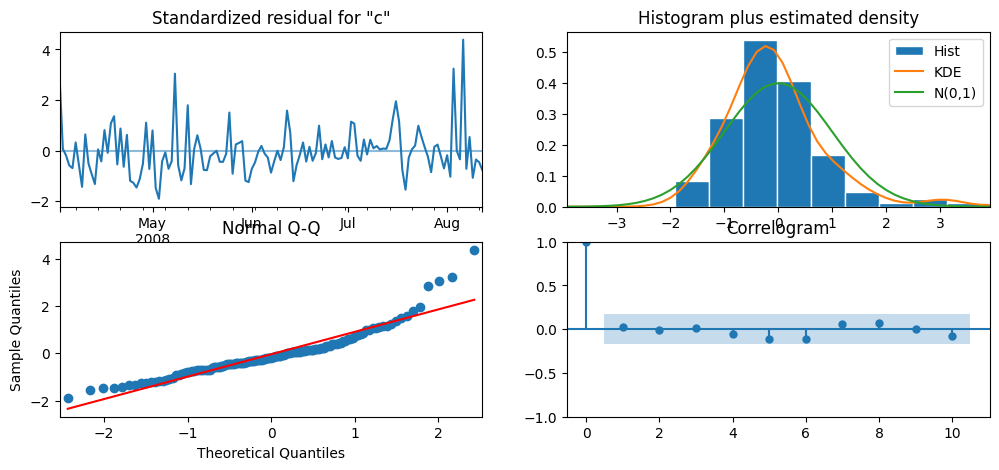

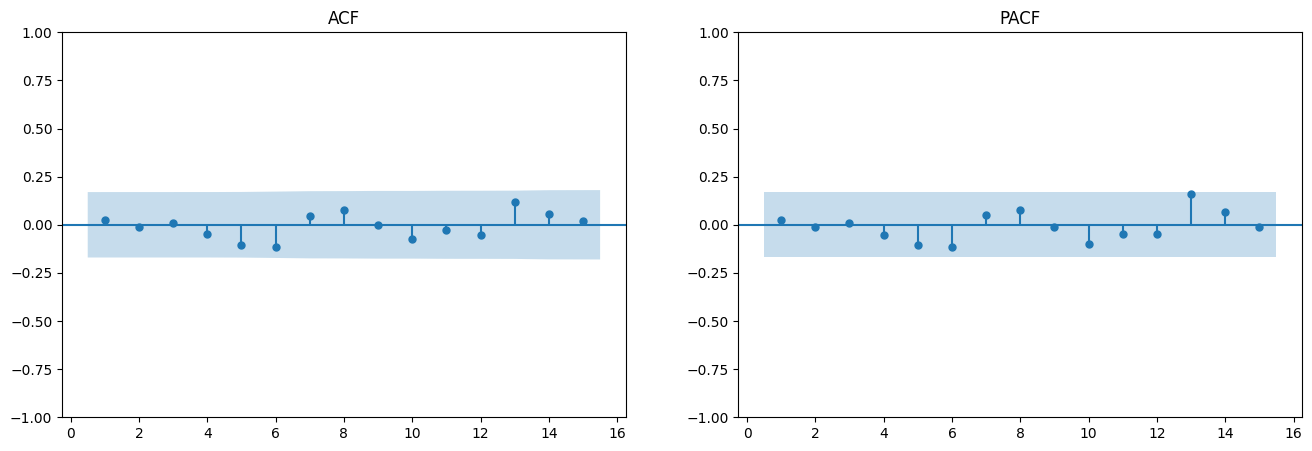

In [12]:
model1 = SARIMAX(y, order=(0,1,1)).fit(disp=False)
diagnostico(model1)

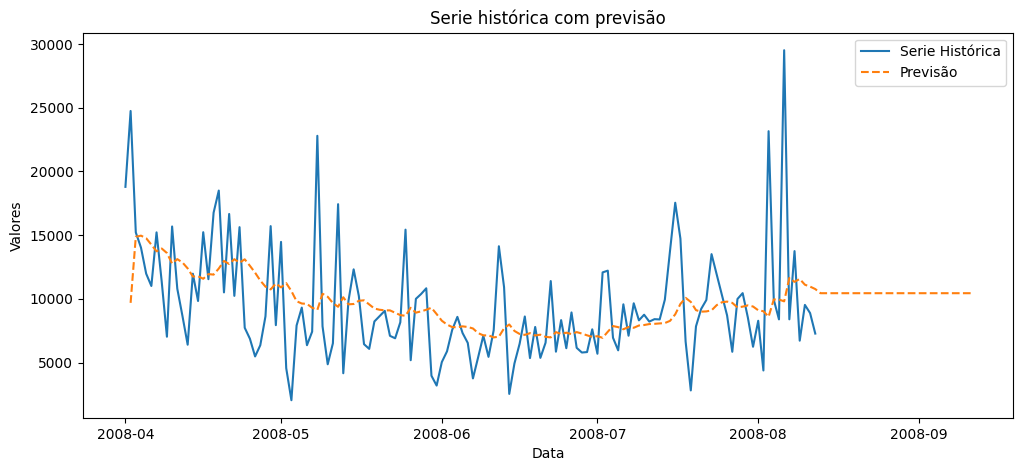

BIC = 2612 - Training ASE = 4601


In [26]:
forecast = model1.forecast(30)
previsao = model1.fittedvalues[1:]
previsao1 = pd.concat([previsao, forecast])
rmse = np.sqrt(np.mean(model1.resid**2))
bic = model1.bic
plot_forecast(y,previsao1)
print(f'BIC = {round(bic)} - Training ASE = {round(rmse)}')

Ok, BIC = 2612, RMSE = 4601 não sei se é bom, mas vamos explorar como melhorar o modelo. Talvez com uma Regressão:

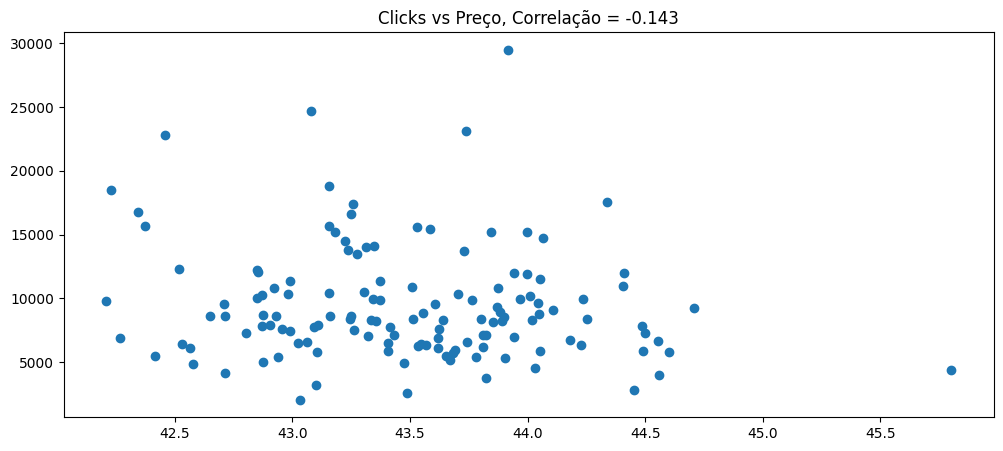

In [28]:
x = df['price']
correl = round(y.corr(x),3)
plt.scatter(x, y)
plt.title(f'Clicks vs Preço, Correlação = {correl}')
plt.show()

In [30]:
import statsmodels.api as sm
x = sm.add_constant(x)
model2 = sm.OLS(y, x).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 clicks   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.759
Date:                Sun, 16 Mar 2025   Prob (F-statistic):             0.0991
Time:                        21:17:43   Log-Likelihood:                -1315.2
No. Observations:                 134   AIC:                             2634.
Df Residuals:                     132   BIC:                             2640.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.549e+04   2.77e+04      2.003      0.0

In [41]:
df.index[-1]

Timestamp('2008-08-12 00:00:00')

In [45]:
media_preco = df['price'].mean()
preco_futuro = pd.Series([media_preco]*30, index = pd.date_range(start=df.index[-1], periods=30))
model2.predict(sm.add_constant(preco_futuro))


/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)


ValueError: shapes (30,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

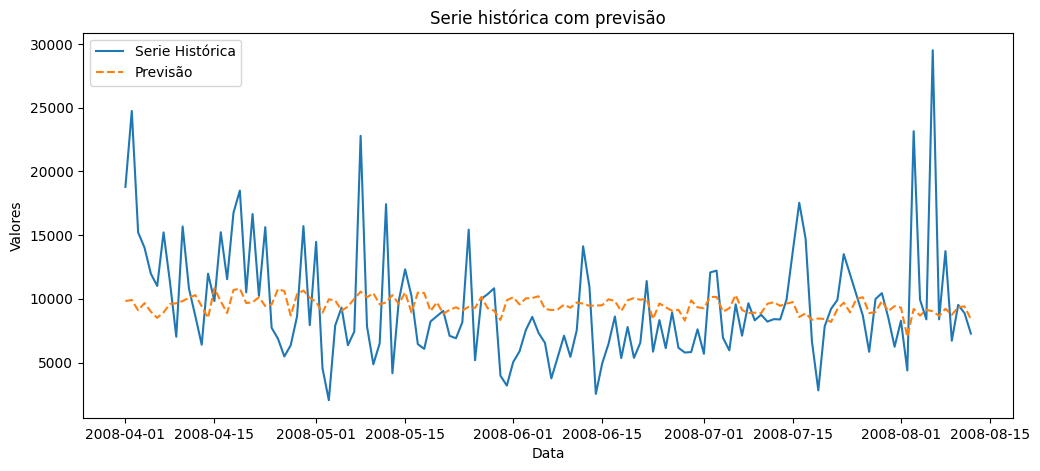

BIC = 2640 - Training ASE = 4429


In [ ]:
media_preco = df['price'].mean()
preco_futuro = [media_preco]*30
forecast = model2.predict(sm.add_constant(preco_futuro))
previsao = model2.fittedvalues
previsao1 = pd.concat([previsao, forecast])

previsao2 = model2.fittedvalues
rmse = np.sqrt(np.mean(model2.resid**2))
bic = model2.bic
plot_forecast(y, previsao2)
print(f'BIC = {round(bic)} - Training ASE = {round(rmse)}')

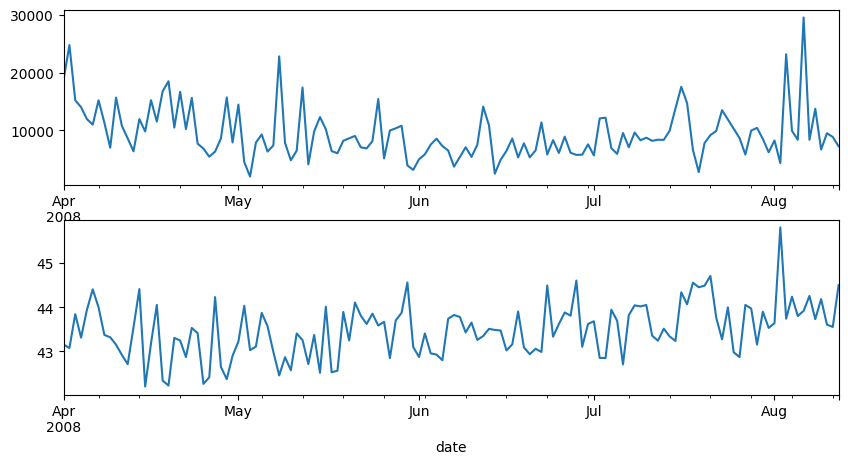

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
y.plot(ax=ax[0])
x.plot(ax=ax[1])
plt.show()

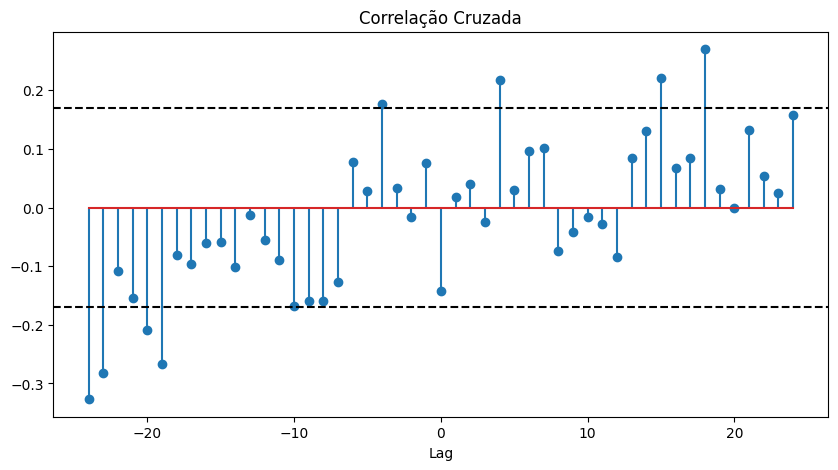

In [31]:
correlacao_cruzada(y,x)

                               SARIMAX Results                                
Dep. Variable:                 clicks   No. Observations:                  134
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1334.829
Date:                Sun, 16 Mar 2025   AIC                           2675.657
Time:                        19:28:42   BIC                           2684.328
Sample:                    04-01-2008   HQIC                          2679.181
                         - 08-12-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price      -1828.6536    402.898     -4.539      0.000   -2618.319   -1038.989
ma.L1         -0.1283      0.024     -5.285      0.000      -0.176      -0.081
sigma2      1.892e+07      0.025   7.44e+08      0.0

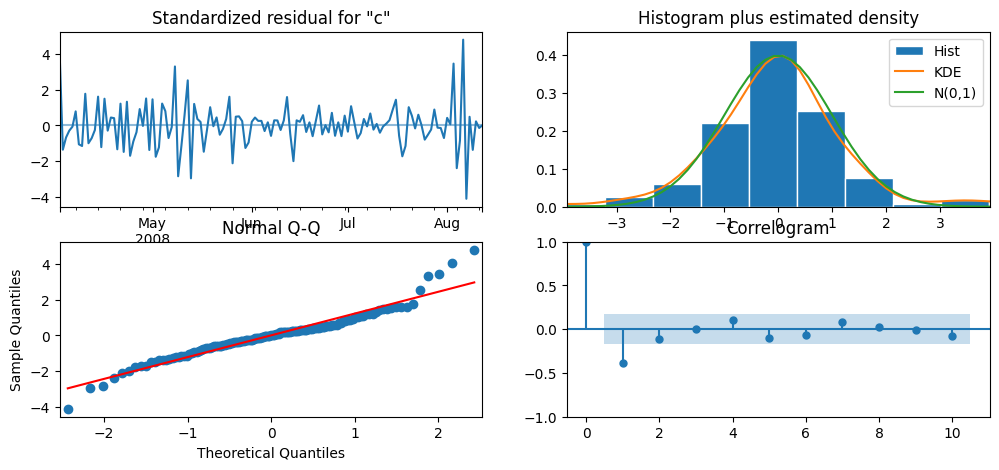

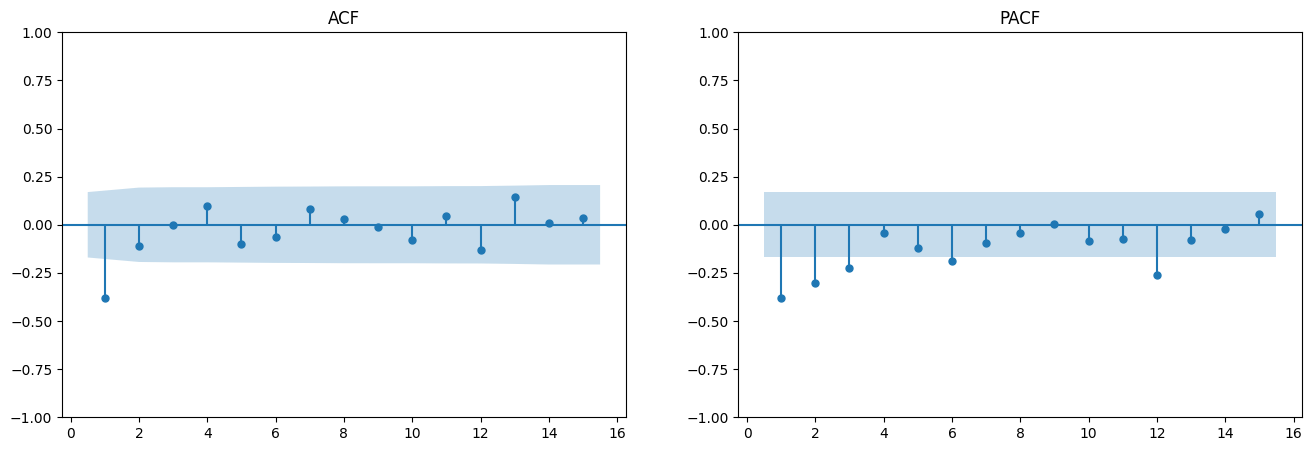

In [36]:
model2 = SARIMAX(y, order = (0,1,1), exog=x).fit(disp=False)
diagnostico(model2)

In [6]:
preco_f = [45]*24

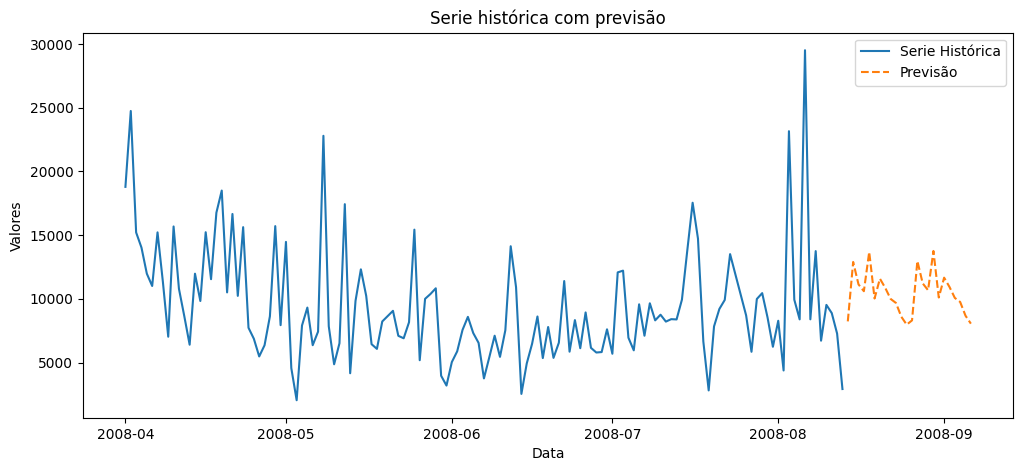

In [7]:
previsao1 = model1.get_forecast(steps=24, exog=preco_f).predicted_mean
plot_forecast(df['clicks'], previsao1)


In [8]:
df['price_4'] = df['price'].shift(4)
df = df.dropna()
model2 = SARIMAX(df['clicks'], order = (0,1,1), seasonal_order=(0,1,1,12), exog=df['price_4']).fit(disp=False)

/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             clicks   No. Observations:                  131
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1160.743
Date:                            Fri, 14 Mar 2025   AIC                           2329.485
Time:                                    20:07:34   BIC                           2340.568
Sample:                                04-05-2008   HQIC                          2333.985
                                     - 08-13-2008                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price_4      265.4741     75.870      3.499      0.000     116.771     414.177
ma.L1         -0.9082      0.051    -17.884      0.000      -1.008      -0.809
ma.S.L12      -0.8678      0.156     -5.546      0.000      -1.174      -0.561
sigma2      1.888e+07      0.000   9.41e+10      0.000    1.89e+07    1.89e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               125.35
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.32   Skew:                             1.40
Prob(H) (two-sided):                  0.39   Kurtosis:                         7.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.54e+26. Standard errors may be unstable.
"""

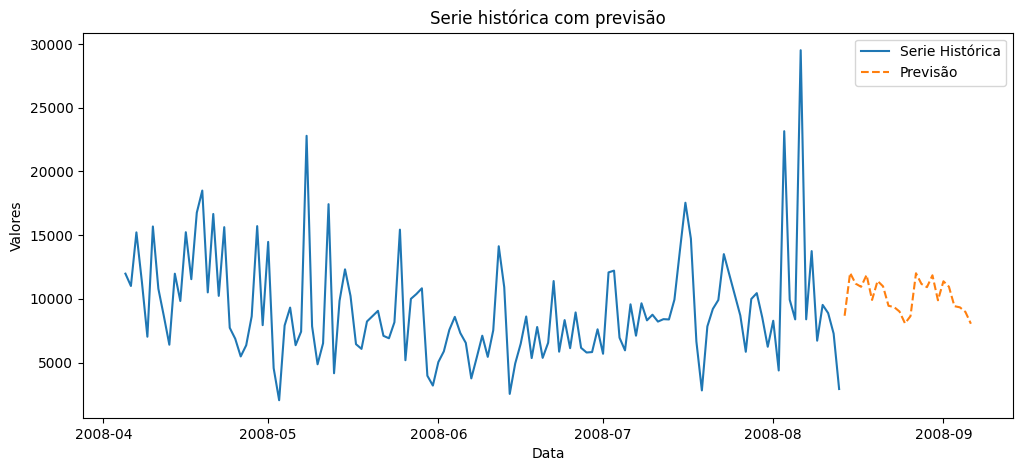

In [10]:
previsao2 = model2.get_forecast(steps=24, exog=preco_f).predicted_mean
plot_forecast(df['clicks'], previsao2)

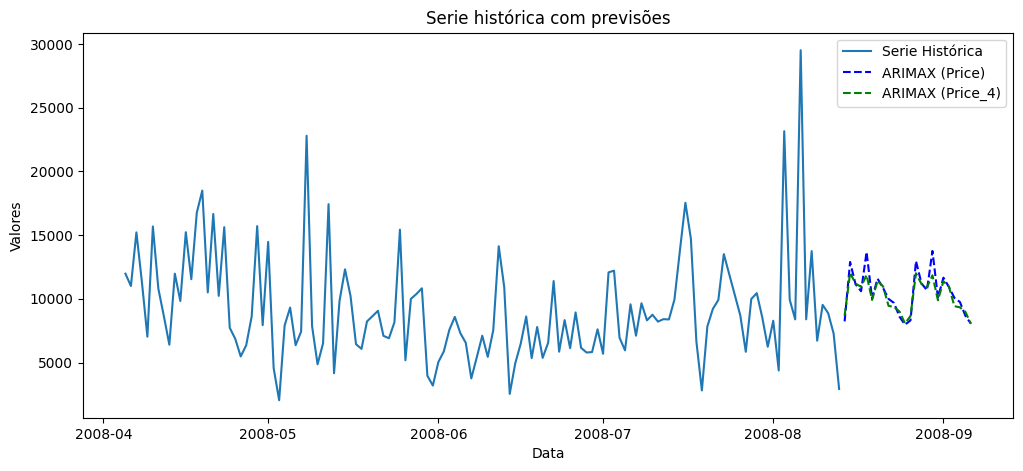

In [11]:
compara_previsoes(df['clicks'], [previsao1,previsao2], ['ARIMAX (Price)', 'ARIMAX (Price_4)'])

In [12]:
passos = 24
preco_medio = df['price'].mean()
preco_medio_f = [preco_medio]*passos
preco_min_f = [30]*passos


previsao1 = model1.get_forecast(steps=24, exog=preco_medio_f).predicted_mean
previsao2 = model1.get_forecast(steps=24, exog=preco_min_f).predicted_mean

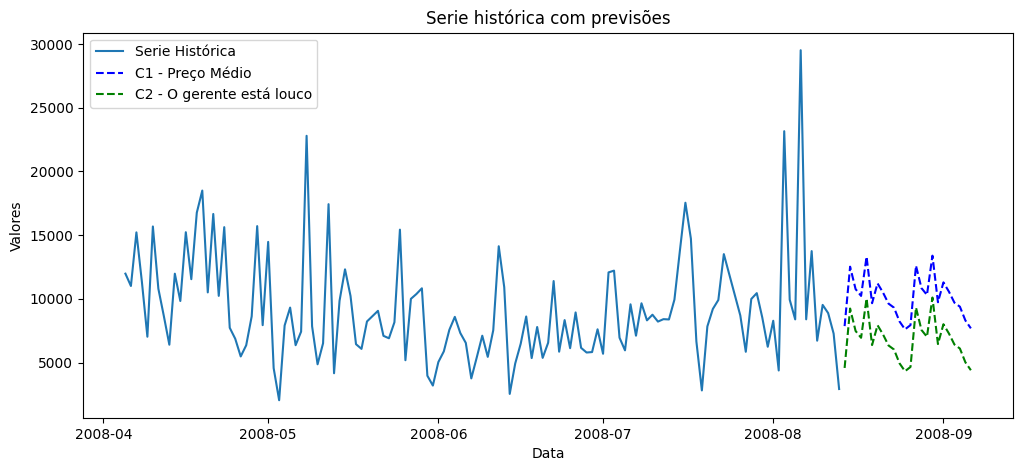

In [13]:
compara_previsoes(df['clicks'], [previsao1,previsao2], ['C1 - Preço Médio', 'C2 - O gerente está louco'])